# Clase 3 — Reducción de dimensionalidad

**Maestría en Bioinformática y Biología de Sistemas — UNNOBA**
**Reconocimiento de Patrones en Bioinformática**

---

## Objetivos de esta clase

En la **Clase 2** atacamos el problema p ≫ n **seleccionando** un subconjunto de variables. Funciona cuando existe un puñado claro de "variables clave". Hoy lo atacamos por el otro lado: **proyectamos** todo el espacio a una dimensión más baja, combinando las variables originales en nuevas que resumen la información.

Este enfoque sirve cuando la señal está **distribuida** en muchas variables correlacionadas — algo típico en biología (módulos de genes co-regulados, programas de expresión, redes metabólicas).

Al final de la hora vas a poder:

1. Distinguir entre **selección** (Clase 2) y **extracción** de variables (hoy).
2. Aplicar **PCA** entendiendo qué son scores, loadings, varianza explicada y scree plot, y cuándo escalar.
3. Aplicar **t-SNE** y entender el rol crítico de `perplexity`. Reconocer qué se puede y qué NO se puede leer de un t-SNE.
4. Aplicar **UMAP** y compararlo con t-SNE en velocidad y preservación de estructura global.
5. Saber cuándo conviene cada técnica y cómo combinarlas en un pipeline real de bioinformática.

## Cómo está organizada la clase

- **Bloque 1 :** Selección vs extracción. Datasets de hoy.
- **Bloque 2 :** PCA en profundidad. **Ejercicio 1.**
- **Bloque 3 :** t-SNE y el problema de la no linealidad. **Ejercicio 2.**
- **Bloque 4 :** UMAP. **Ejercicio 3.**
- **Bloque 5 :** Comparación práctica. **Ejercicio 4.**
- **Cierre :** **Ejercicio 5** integrador.

In [ ]:
# !pip install umap-learn --quiet

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Setup listo.")

Setup listo.


---

# Bloque 1 — Selección vs extracción

## Dos formas de bajar la dimensión

Tenés un dataset con $p$ variables y querés trabajar con menos. Hay dos caminos conceptualmente distintos:

**Selección** (Clase 2): elegís un **subconjunto** de las variables originales y descartás el resto. Si tu dataset tiene los genes BRCA1, TP53, EGFR... terminás con BRCA1 y TP53, descartando EGFR. Las variables que quedan son exactamente las originales, conservan su nombre y su interpretación biológica directa.

**Extracción** : construís **variables nuevas** combinando las originales. PC1 podría ser "0.3·BRCA1 + 0.7·TP53 − 0.2·EGFR + ...". Las variables nuevas no son ningún gen específico: son **combinaciones** que capturan patrones de variación en el dataset.

| | Selección (Clase 2) | Extracción |
|---|---|---|
| **Qué hace** | Elige un subconjunto de las variables originales | Construye nuevas variables combinando las originales |
| **Interpretabilidad** | Directa (gen X importa) | Indirecta (PC1 = combinación lineal de muchos genes) |
| **Usa la respuesta y?** | Sí (filtros, wrappers, embedded usan y) | No necesariamente (PCA, t-SNE, UMAP son **no supervisados**) |
| **Salida típica** | Conjunto de índices o nombres de variables | Matriz $n \times k$ con $k \ll p$ |
| **Aplicación clínica** | Panel diagnóstico de pocos genes | Visualización exploratoria, pre-procesamiento |

## Cuándo conviene cada paradigma

**Selección** funciona bien cuando hay un pequeño grupo de variables fuertemente predictivas (firmas génicas, biomarcadores discretos). Sirve para **diagnóstico clínico** y **paneles** que requieren un número finito de mediciones.

**Extracción** funciona bien cuando la señal está **distribuida** entre muchas variables correlacionadas, por ejemplo:
- Módulos de genes co-regulados (cientos de genes activándose juntos por una vía metabólica).
- Estructura poblacional en genética (la información sobre origen geográfico está repartida en miles de SNPs).
- Tipos celulares en single-cell (cada tipo se define por programas de expresión enteros, no por uno o dos genes).

En estos casos, descartar variables individuales pierde información. Combinarlas en componentes que capturan la variación conjunta es más eficiente.

**En la práctica se combinan**: primero selección para descartar ruido grueso, después extracción para resumir lo que queda. Lo vemos al final de la clase.

## Una propiedad importante: técnicas no supervisadas

PCA, t-SNE y UMAP son **no supervisados**: no usan la variable respuesta `y` (la clase, el fenotipo) para nada. Solo miran la estructura interna de `X`.

Esto tiene consecuencias importantes:
- **No hay riesgo de data leakage por la transformación misma** (no usan `y`).
- Pero **tampoco hay garantía** de que las componentes que encuentran sean buenas para predecir `y`. PCA encuentra direcciones de máxima varianza, no de máxima separabilidad de clases.
- Cuando se usan para visualización, los grupos que se ven en el plot **no necesariamente** corresponden a las clases que te interesan.

## Los datasets de hoy

Vamos a usar dos datasets complementarios:

**1. Digits (sklearn).** 1797 imágenes 8×8 de dígitos manuscritos (0-9). Son 64 features (los píxeles) y 10 clases. Pequeño, bien conocido, con estructura no lineal clara (los dígitos forman "manifolds" curvos en el espacio de píxeles). Ideal para ganar intuición visual.

**2. PBMC sintético.** Imita un experimento de single-cell RNA-seq: 1000 células de 4 tipos celulares distintos, medidas en 500 genes. De los 500 genes, solo 50 son **marcadores** que diferencian tipos celulares; los otros 450 son ruido sistemático común a todas las células. Esta estructura (poca señal en un mar de ruido) es típica de los datos ómicos reales.

Digits: X = (1797, 64), clases = 10


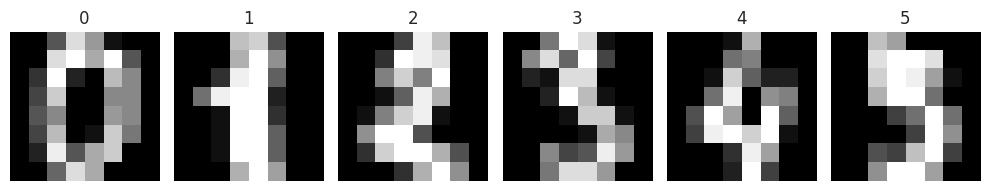

In [2]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Digits: X = {X_digits.shape}, clases = {len(np.unique(y_digits))}")

# Mostrar algunos ejemplos
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for ax, img, label in zip(axes, digits.images[:6], digits.target[:6]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# Generamos el dataset PBMC sintético: 4 tipos celulares × ~250 células c/u
rng = np.random.RandomState(0)
n_per_cluster = 250
n_clusters = 4
p_genes = 500
n_marker = 50   # genes marcadores: los primeros 50 separan tipos celulares

# Centros aleatorios para cada tipo celular en los genes marcadores
centros_marker = rng.randn(n_clusters, n_marker) * 3.0
# El resto de los genes no tiene señal sistemática (ruido común a todas las células)
centros_resto = np.zeros((n_clusters, p_genes - n_marker))
centros = np.hstack([centros_marker, centros_resto])

X_pbmc = np.vstack([
    centros[k] + rng.randn(n_per_cluster, p_genes) * 1.0
    for k in range(n_clusters)
])
y_pbmc = np.repeat(np.arange(n_clusters), n_per_cluster)

# Nombres de los "tipos celulares"
tipos_celulares = ["T cell", "B cell", "Monocito", "NK cell"]

print(f"PBMC sintético: X = {X_pbmc.shape}, tipos = {n_clusters}")
print(f"Genes marcadores (con señal): {n_marker}")
print(f"Genes ruido: {p_genes - n_marker}")

PBMC sintético: X = (1000, 500), tipos = 4
Genes marcadores (con señal): 50
Genes ruido: 450


---

# Bloque 2 — Análisis de Componentes Principales (PCA)

## La intuición geométrica

Imaginá una nube de puntos en 3 dimensiones que parece un cigarrillo: alargada en una dirección, achatada en las otras dos. **PCA encuentra la dirección del eje largo del cigarrillo** (PC1), después la dirección perpendicular más larga (PC2), y así sucesivamente.

Cada **componente principal** es una dirección en el espacio original que captura tanta variación de los datos como sea posible, sujeto a ser perpendicular a las componentes anteriores.

Las propiedades clave:

- PC1 captura la **mayor varianza posible** en una sola dirección.
- PC2 captura la **mayor varianza restante** entre las direcciones perpendiculares a PC1.
- Las PCs son **ortogonales** entre sí (decorrelacionadas por construcción).
- Si los datos viven cerca de un subespacio de dimensión $k$, las primeras $k$ PCs capturan casi toda la varianza, y el resto es ruido.

## La matemática mínima

Sea $X$ una matriz $n \times p$ con los datos **centrados** (cada columna con media cero). PCA hace una descomposición en valores singulares:

$$X = U \Sigma V^T$$

donde:
- $V$ es $p \times p$ y sus columnas son los **loadings**: las direcciones (vectores en el espacio original) de las componentes principales.
- $U \Sigma$ es $n \times p$ y sus columnas son los **scores**: las coordenadas de los puntos en el nuevo sistema.
- $\Sigma$ es diagonal con los **valores singulares** $\sigma_1 \geq \sigma_2 \geq ...$: cuán "grande" es cada componente.

La **varianza explicada** por la componente $j$ es proporcional a $\sigma_j^2$. La **proporción de varianza explicada** por PC$j$ es $\sigma_j^2 / \sum_k \sigma_k^2$.

**Loadings vs scores — la confusión más común:**
- **Loadings** (vectores de $p$ elementos): la "receta" para construir cada PC desde las variables originales. "PC1 es 0.3 veces el gen A más 0.5 veces el gen B menos 0.1 veces el gen C..."
- **Scores** (vectores de $n$ elementos): los valores de cada muestra en cada PC. "El paciente 1 tiene un valor de 2.3 en PC1, el paciente 2 tiene -1.4, etc."

Cuando ploteás PC1 vs PC2, estás ploteando **scores**. Cuando preguntás "qué genes pesan en PC1", estás mirando **loadings**.

## Diagnóstico: el scree plot

¿Cuántas componentes hay que retener? La herramienta estándar es el **scree plot**: gráfico de varianza explicada por componente, ordenadas decrecientemente.

Tres lecturas posibles:

1. **Codo:** si hay un "salto" claro entre PC$k$ y PC$k+1$, las primeras $k$ son señal y el resto es ruido.
2. **Umbral acumulado:** retener tantas PCs como hagan falta para explicar el 80%, 90% o 95% de la varianza total. Es el criterio más usado en bioinformática.
3. **Test estadístico (Marchenko-Pastur, parallel analysis):** comparar el espectro contra lo esperable bajo ruido puro. Más riguroso pero menos usado en la práctica diaria.

## ¿Escalar antes de PCA?

**Esto importa muchísimo.** PCA encuentra direcciones de **máxima varianza**. Si tus variables están en escalas distintas (gen A entre 0-1, gen B entre 100-10000), la varianza de B va a dominar y PC1 va a estar dictada esencialmente por B, ignorando A. No porque B sea biológicamente más importante, sino por su escala.

**Reglas prácticas:**

| Situación | Escalar? |
|---|---|
| Variables en escalas muy distintas (medidas físicas heterogéneas) | **Sí**, siempre |
| Datos ya normalizados (log-CPM de RNA-seq, intensidades log-transformadas de microarray) | Opcional, suele convenir igual |
| Todas las variables miden lo mismo en la misma escala (píxeles de una imagen, expresión de genes después de log-normalización) | A veces no escalar es preferible |

Para el PBMC sintético de hoy, **no vamos a escalar** porque todas las variables ya están en una escala común y escalar amplificaría los 450 genes ruido respecto a los 50 marcadores. En datos reales (microarrays, RNA-seq sin transformar), escalar suele ser necesario.

## PCA en práctica

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Para este dataset sintético todas las variables ya están en la misma escala,
# así que NO estandarizamos (estandarizar amplifica los genes ruido).
# Pero en datos reales (microarray sin log-transformar) ESCALAR es importante.

# PCA con varias componentes para ver la varianza
pca_full = PCA(n_components=50)
X_pca_full = pca_full.fit_transform(X_pbmc)

print(f"X después de PCA: {X_pca_full.shape}")
print(f"Varianza explicada por las primeras 10 PCs:")
for i, v in enumerate(pca_full.explained_variance_ratio_[:10]):
    print(f"  PC{i+1}: {v*100:.1f}%")
print(f"\nAcumulada en 10 PCs: {pca_full.explained_variance_ratio_[:10].sum()*100:.1f}%")
print(f"Acumulada en 50 PCs: {pca_full.explained_variance_ratio_[:50].sum()*100:.1f}%")

X después de PCA: (1000, 50)
Varianza explicada por las primeras 10 PCs:
  PC1: 19.2%
  PC2: 14.4%
  PC3: 9.5%
  PC4: 0.3%
  PC5: 0.3%
  PC6: 0.3%
  PC7: 0.3%
  PC8: 0.3%
  PC9: 0.3%
  PC10: 0.3%

Acumulada en 10 PCs: 45.3%
Acumulada en 50 PCs: 55.7%


**Cómo leer la salida:**

Si todo va como esperamos, vas a ver algo como:
- PC1 ≈ 19%, PC2 ≈ 14%, PC3 ≈ 10% (las primeras 3 PCs solas explican ~43% de la varianza).
- PC4 en adelante: cada una alrededor de 0.3% (ruido puro).

Este **salto brusco** entre PC3 y PC4 es el "codo" del scree plot: nos dice que **hay 3 componentes con señal real y el resto es ruido**. ¿Por qué 3 componentes para 4 grupos? Porque para separar 4 puntos en el espacio (los centros de los 4 tipos celulares) basta con 3 dimensiones — análogo a que un triángulo vive en un plano y un tetraedro en 3D.

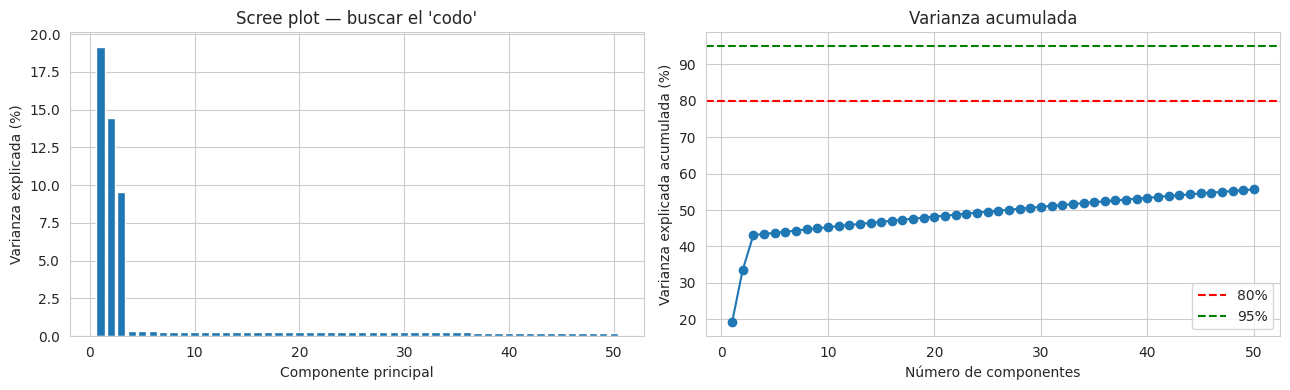

In [13]:
# Scree plot: varianza explicada por componente
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, 51), pca_full.explained_variance_ratio_ * 100)
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Scree plot — buscar el 'codo'")

axes[1].plot(range(1, 51), np.cumsum(pca_full.explained_variance_ratio_) * 100, "o-")
axes[1].axhline(80, color="red", linestyle="--", label="80%")
axes[1].axhline(95, color="green", linestyle="--", label="95%")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza explicada acumulada (%)")
axes[1].set_title("Varianza acumulada")
axes[1].legend()

plt.tight_layout()
plt.show()

**Qué mirar en estos gráficos:**

- **Scree plot (izquierda):** el codo después de PC3 indica que la señal está en las primeras 3 componentes. PC4 en adelante son ruido individual.
- **Varianza acumulada (derecha):** muestra cuántas PCs hacen falta para explicar 80% (línea roja) o 95% (línea verde) de la varianza total. Notá que para llegar a 80% necesitamos bastantes componentes — esto es porque los 450 genes ruido tienen cada uno una pizca de varianza que se va sumando lentamente.

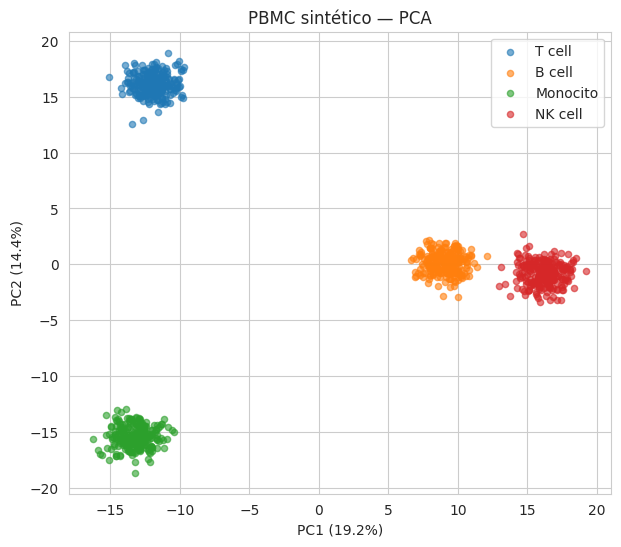

In [14]:
# Visualización de los datos en PC1 vs PC2
plt.figure(figsize=(7, 6))
for k in range(n_clusters):
    plt.scatter(X_pca_full[y_pbmc == k, 0], X_pca_full[y_pbmc == k, 1],
                label=tipos_celulares[k], alpha=0.6, s=20)
plt.xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PBMC sintético — PCA")
plt.legend()
plt.show()

**Lectura del gráfico:**

Cada punto es una célula, proyectada sobre las dos primeras componentes principales. Los colores son la etiqueta real (tipo celular). **Notá que PCA no usó las etiquetas para nada** — los grupos se separan solos porque los tipos celulares tienen perfiles de expresión génica distintos, y eso se traduce en direcciones de máxima varianza diferentes para cada grupo.

Lo interesante: con solo **2 componentes** de 500 variables originales, ya se ven 4 grupos razonablemente diferenciados. Esa es la magia de PCA cuando hay estructura lineal.

> **Importante:** este es un dataset sintético donde PCA funciona muy bien. En single-cell real con tipos celulares que se diferencian de forma sutil, PC1 vs PC2 muchas veces no alcanza para verlos separados y hay que recurrir a t-SNE/UMAP (próximos bloques) o usar más componentes.

## Ejercicio 1 — PCA en digits

**Tu tarea:**

a) Aplicá PCA al dataset de **digits**. ¿Cuántas componentes necesitás para explicar el 80% de la varianza? ¿Y el 95%?

b) Hacé un scatter plot de PC1 vs PC2, coloreando por dígito. ¿Se separan visualmente todos los grupos? ¿Algunos se confunden?

c) Mirá los **loadings** de las primeras 4 PCs. Cada loading es un vector de 64 valores, que podés reordenar a 8×8 y visualizar como una imagen. ¿Qué patrones del dígito captura cada PC?

**Pista para c):** los loadings están en `pca.components_`, una matriz de forma `(n_components, n_features)`. `pca.components_[0]` es el vector de 64 valores que define PC1. Para verlo como imagen 8×8: `pca.components_[0].reshape(8, 8)` y plotear con `imshow`.

In [ ]:
# TU CÓDIGO ACÁ
# a) PCA sobre digits
scaler_d = StandardScaler()
X_digits_s = scaler_d.fit_transform(X_digits)

# ¿Cuántas componentes para 80% y 95%?

# b) Scatter PC1 vs PC2

# c) Loadings de PC1 como imagen 8x8 (pca.components_[0].reshape(8, 8))

> **Por qué SÍ escalamos digits y NO escalamos PBMC:** los píxeles de digits tienen valores entre 0 y 16 (escala de grises 4-bit), pero algunos píxeles (los del centro de la imagen) tienen mucha más variabilidad que otros (las esquinas, casi siempre 0). Sin escalar, PCA estaría dominado por los píxeles centrales por su mayor varianza. Escalando, cada píxel pesa por igual y PCA descubre patrones más interesantes.

---

# Bloque 3 — t-SNE: estructura no lineal

## El límite de PCA

PCA es una transformación **lineal**: cada PC es una combinación lineal de las variables originales. Eso funciona cuando los datos viven cerca de un subespacio lineal (un plano, un hiperplano, etc).

Pero muchos datos biológicos no se ajustan a esa forma. Imaginá células diferenciándose en el tiempo a lo largo de una trayectoria curva en el espacio de expresión génica. Esa trayectoria es no lineal — proyectarla sobre un plano la "aplasta" y se pierde la estructura.

**t-SNE** (t-distributed Stochastic Neighbor Embedding) es una técnica **no lineal** diseñada específicamente para visualización. Su objetivo es distinto al de PCA: en vez de maximizar varianza, busca **preservar la estructura de vecindad local**.

## La idea conceptual

t-SNE construye dos distribuciones de probabilidad:

1. **En el espacio alto-dimensional** ($\mathbb{R}^p$): para cada punto $x_i$, define $p_{ij}$ como la probabilidad de que $x_j$ sea "vecino" de $x_i$. Cuanto más cerca esté $x_j$ de $x_i$, mayor $p_{ij}$.
2. **En el espacio bajo-dimensional** ($\mathbb{R}^2$, donde queremos visualizar): para cada punto $y_i$ (la imagen de $x_i$ en 2D), define $q_{ij}$ análogamente.

Después busca las posiciones $y_i$ en 2D que hacen que las dos distribuciones se parezcan lo más posible, minimizando la divergencia de Kullback-Leibler entre $P$ y $Q$:

$$\text{KL}(P \| Q) = \sum_{i,j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

**Traducción humana:** los puntos que son vecinos en alta dimensión van a quedar vecinos en 2D. Los puntos que están lejos en alta dimensión pueden quedar a cualquier distancia en 2D (porque el algoritmo "no se preocupa" tanto por eso).

## El parámetro crítico: perplexity

`perplexity` controla cuántos vecinos efectivos considera cada punto al construir $P$. Valores típicos: 5 a 50.

- **Perplexity baja (5-10):** se concentra en estructura muy local. Cada punto "mira" solo a sus 5 vecinos más cercanos. Resultado: clusters bien definidos pero pueden fragmentarse en sub-grupos espurios.
- **Perplexity media (20-50):** balance estándar. Es el rango recomendado en casi todas las aplicaciones.
- **Perplexity alta (>100):** se considera vecindario amplio. Puede borrar separaciones finas entre clusters cercanos.

**Regla práctica:** empezar con `perplexity=30`. Si la visualización no convence, probar 10 y 50. Si las tres dan resultados muy distintos, **desconfiar del análisis** — probablemente no hay estructura clara y t-SNE está "inventando" patrones.

## Las advertencias críticas de t-SNE

t-SNE es una de las técnicas más mal interpretadas del machine learning. Las siguientes propiedades son **fundamentales**:

**1. Las distancias entre clusters NO son interpretables.** Si en tu plot dos clusters están "lejos" y otros dos están "cerca", **eso no significa nada biológico**. t-SNE optimiza la estructura local; las distancias globales son arbitrarias.

**2. Los tamaños de los clusters NO son interpretables.** Un cluster grande en el plot no significa que tenga más varianza interna, ni más muestras importantes. t-SNE tiende a "expandir" clusters densos y "comprimir" los dispersos.

**3. t-SNE es estocástico.** Cada corrida puede dar un resultado distinto (rotado, reflejado, con clusters en otras posiciones). Para reproducibilidad: fijar `random_state`.

**4. t-SNE no se generaliza a datos nuevos.** No hay una función "transformar" que aplique el mismo mapeo a una muestra nueva. Si llega un paciente nuevo, hay que correr t-SNE de nuevo con todo el dataset. Por eso **NO se usa para predicción**, solo para visualización.

**Lo único que SÍ es interpretable de un t-SNE:** la pertenencia de cada punto a un cluster, y qué otros puntos son sus vecinos cercanos. Punto.

## Pre-procesamiento estándar: PCA antes de t-SNE

t-SNE escala mal con el número de dimensiones. La práctica estándar (y lo que hace por default `scanpy` en single-cell) es:

1. Aplicar PCA con 30-50 componentes.
2. Aplicar t-SNE sobre esas PCs (no sobre las variables originales).

Esto acelera enormemente el cálculo y suele dar mejores resultados porque **filtra ruido de alta frecuencia** que solo confunde a t-SNE.

## t-SNE en práctica

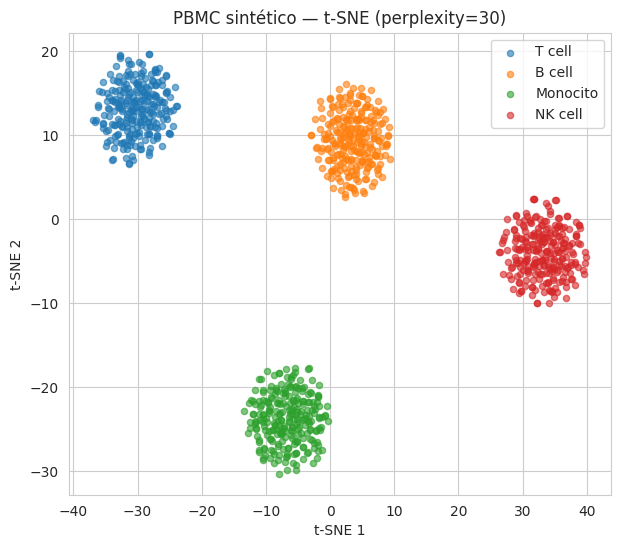

In [15]:
from sklearn.manifold import TSNE

# Pre-PCA: t-SNE se aplica típicamente sobre las primeras 30-50 PCs (más rápido)
pca_pre = PCA(n_components=30)
X_pbmc_pca30 = pca_pre.fit_transform(X_pbmc)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=0, init="pca")
X_tsne = tsne.fit_transform(X_pbmc_pca30)

# Visualización
plt.figure(figsize=(7, 6))
for k in range(n_clusters):
    plt.scatter(X_tsne[y_pbmc == k, 0], X_tsne[y_pbmc == k, 1],
                label=tipos_celulares[k], alpha=0.6, s=20)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("PBMC sintético — t-SNE (perplexity=30)")
plt.legend()
plt.show()

**Lectura del gráfico:**

A diferencia del scatter de PCA donde los 4 tipos celulares se separaban pero quedaban a distancias proporcionales a sus diferencias reales, en t-SNE vas a ver los 4 grupos como **islas bien definidas**, completamente separadas, con espacio en blanco entre ellas.

Esa "limpieza visual" es atractiva pero **engañosa**: las distancias entre las islas no significan que esos tipos celulares sean "más" o "menos" parecidos. Lo único que podés afirmar es que dentro de cada isla, las células son verdaderamente similares entre sí.

##  Ejercicio 2 — Sensibilidad a perplexity

**Tu tarea:**

Aplicá t-SNE al PBMC sintético con `perplexity` en $\{5, 30, 100\}$. Graficá los tres lado a lado.

Preguntas para reflexionar:

a) ¿Qué cambia visualmente entre las tres corridas?
b) ¿Algún cluster se fragmenta con perplexity bajo? ¿Algunos se fusionan con perplexity alto?
c) Si tuvieras que reportar UN solo gráfico, ¿cuál elegirías y por qué?

**Cuidado:** este ejercicio es importante para internalizar que t-SNE no tiene "la" respuesta correcta — tiene una familia de respuestas dependiendo de los hiperparámetros. La crítica de un paper que reporta un t-SNE con un solo perplexity sin justificarlo es válida.

In [ ]:
# TU CÓDIGO ACÁ
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Para cada perplexity:
#   1. Ajustar TSNE(n_components=2, perplexity=p, random_state=0, init="pca")
#      sobre X_pbmc_pca30
#   2. Plotear coloreando por y_pbmc
#   3. Poner título con el valor de perplexity

---

# Bloque 4 — UMAP

## El sucesor moderno de t-SNE

UMAP (Uniform Manifold Approximation and Projection) apareció en 2018 y se convirtió rápidamente en el estándar de facto para visualización en single-cell y otras áreas. Comparado con t-SNE:

| Propiedad | t-SNE | UMAP |
|---|---|---|
| Estructura local | Excelente | Excelente |
| Estructura global | Mala (distancias entre clusters no significan nada) | Mejor (algo de información global se preserva) |
| Velocidad en datasets grandes | Lento (O(n²)) | Rápido (O(n log n) aproximadamente) |
| Determinismo | Estocástico | Determinista con seed fijo |
| Generalización a datos nuevos | No tiene | **Sí**, hay `transform()` |
| Año | 2008 | 2018 |

## La idea conceptual

UMAP se basa en teoría de **variedades topológicas** (manifold theory) y **teoría de grafos**. Sin entrar en la matemática, la idea es:

1. Construir un grafo en alta dimensión donde cada punto está conectado con sus vecinos más cercanos, con pesos que reflejan la "confianza" de cada conexión.
2. Encontrar un layout en 2D (o 3D) que preserve la **estructura del grafo** lo mejor posible.

La diferencia clave con t-SNE: UMAP modela explícitamente la estructura local **y** global como un único objeto matemático (el grafo difuso topológico), entonces hace un mejor trabajo manteniendo ambas a la vez.

## Parámetros clave

**`n_neighbors`** (default 15): número de vecinos que cada punto considera al construir el grafo. Análogo a `perplexity` en t-SNE.
- Bajo (5-10): estructura muy local, puede fragmentar clusters.
- Alto (30-50): estructura más global, clusters más amontonados.

**`min_dist`** (default 0.1): cuán compactos pueden quedar los puntos cercanos en el layout 2D.
- Bajo (0.0-0.1): clusters densos, puntos muy juntos. Bueno para ver clusters discretos.
- Alto (0.3-0.5): clusters difusos, transición suave. Bueno para ver trayectorias continuas (diferenciación celular).

**Defaults razonables para single-cell:** `n_neighbors=15`, `min_dist=0.1`. Lo que usa `scanpy` por default.

## Una propiedad útil: UMAP se generaliza

A diferencia de t-SNE, UMAP tiene un método `transform()` que aplica el mismo mapeo a datos nuevos:

```python
reducer = umap.UMAP().fit(X_train)
X_train_2d = reducer.transform(X_train)
X_test_2d = reducer.transform(X_test)   # ¡esto NO existe en t-SNE!
```

Esto **no** significa que UMAP sea bueno para predicción (sigue sin serlo, porque la transformación no preserva linealidad), pero sí que podés visualizar datos nuevos en el mismo "mapa" sin tener que recalcular todo.

## Una advertencia importante

UMAP también tiene las mismas limitaciones de interpretación que t-SNE — aunque algo menos severas:
- Las distancias entre clusters tienen **algo** de significado, pero no son métricamente exactas.
- Los tamaños de cluster siguen siendo poco confiables.
- La elección de parámetros sigue afectando el resultado.

**No es una solución mágica.** Es t-SNE mejorado, no t-SNE infalible.

## UMAP en práctica

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


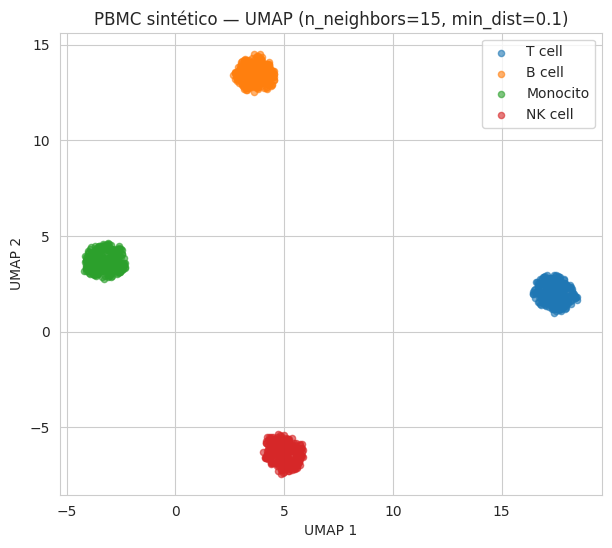

In [16]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,    # default razonable
    min_dist=0.1,      # clusters relativamente compactos
    random_state=0     # reproducibilidad
)
X_umap = reducer.fit_transform(X_pbmc_pca30)

plt.figure(figsize=(7, 6))
for k in range(n_clusters):
    plt.scatter(X_umap[y_pbmc == k, 0], X_umap[y_pbmc == k, 1],
                label=tipos_celulares[k], alpha=0.6, s=20)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("PBMC sintético — UMAP (n_neighbors=15, min_dist=0.1)")
plt.legend()
plt.show()

> **Detalle técnico:** UMAP usa la librería `numba` para compilar el código a velocidad nativa. La **primera vez** que lo importás en una sesión, tarda ~30 segundos en compilar internamente. Después de esa primera vez, es muy rápido. En Colab esto se nota especialmente.

## Ejercicio 3 — UMAP con distintos parámetros

**Tu tarea:**

Aplicá UMAP variando dos parámetros, en una grilla de 2 filas × 3 columnas:

- **Fila 1:** `n_neighbors` en $\{5, 15, 50\}$ (con `min_dist=0.1` fijo).
- **Fila 2:** `min_dist` en $\{0.0, 0.1, 0.5\}$ (con `n_neighbors=15` fijo).

Preguntas:

a) ¿Qué le pasa a los clusters cuando `min_dist=0` (compresión máxima)?
b) ¿Qué pasa con `n_neighbors=5` (vecindario muy chico)?
c) ¿Hay alguna combinación que claramente sea "mejor" para este dataset? ¿O todas son aceptables?

In [ ]:
# TU CÓDIGO ACÁ
# Pista: hacer una grilla de 2 filas x 3 columnas de scatter plots
# Pista 2: para cada subplot, ajustar UMAP con los parámetros indicados
#         y plotear coloreando por y_pbmc

---

# Bloque 5 — Comparación práctica

Vimos PCA, t-SNE y UMAP por separado. Es momento de compararlas en un mismo dataset y derivar reglas prácticas.

## Una métrica cuantitativa: ¿qué tan bien preserva la información de clase?

Hasta ahora juzgamos las visualizaciones "a ojo": ¿se ven los grupos separados? Esto es subjetivo. Una forma cuantitativa de medir si una representación 2D **preserva información útil** es:

> Entrenar un clasificador simple (KNN) sobre la representación 2D, y medir su accuracy con CV. Si los grupos están bien separados, KNN debería andar bien.

Es una proxy: nos dice cuán "predictiva" es la representación, lo cual no es exactamente lo mismo que cuán "fiel" sea geométricamente. Pero es la única métrica cuantitativa razonable que podemos calcular sin tener ground truth de distancias originales.

> **Cuidado:** que t-SNE/UMAP den mejor KNN que PCA en 2D **no** significa que sean "mejores" en general. Solo significa que en estos datos particulares, capturan mejor la separabilidad de clases en pocas dimensiones. PCA con más componentes (30-50) suele igualarlos.

## Ejercicio 4 — Tres técnicas, un dataset

**Tu tarea:**

Sobre el dataset **digits**:

a) Generá tres visualizaciones 2D: PCA, t-SNE, UMAP. Ploteá lado a lado, coloreando por dígito.

b) Para cada una, entrená un KNN (k=5) sobre la representación 2D y reportá la accuracy con CV de 5 folds. ¿Cuál preserva mejor la información de clase?

c) Reflexión: ¿esto significa que t-SNE/UMAP son "mejores" que PCA en general?

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# TU CÓDIGO ACÁ
# a) Tres visualizaciones lado a lado:
#    - PCA(n_components=2) directo sobre X_digits_s
#    - TSNE(n_components=2, perplexity=30) sobre PCs (30 primeras)
#    - umap.UMAP(n_neighbors=15) sobre las mismas PCs

# b) Para cada representación 2D:
#    knn = KNeighborsClassifier(n_neighbors=5)
#    cross_val_score(knn, X_emb, y_digits, cv=5).mean()

# c) Reflexión en una celda Markdown

---

# Cierre — Ejercicio integrador

## Ejercicio 5 — Recomendación de pipeline

Te asignan un proyecto de **single-cell RNA-seq**: 30.000 células, 20.000 genes medidos por célula. Tus objetivos:

1. **Visualizar** los tipos celulares en 2D para una figura del paper.
2. Hacer **clustering** para descubrir tipos celulares previamente no caracterizados.
3. Identificar **genes marcadores** de cada tipo celular descubierto.

Diseñá un pipeline usando lo de las **tres clases hasta ahora** (no solo la de hoy). Tu respuesta debería abordar:

a) ¿Hacés selección de variables antes de la reducción de dimensionalidad? ¿Por qué? ¿Qué tipo?

b) ¿Usás PCA, t-SNE o UMAP — o varios? ¿En qué orden? ¿Para qué cada uno?

c) ¿Cómo identificás los genes marcadores al final?

d) ¿Dónde tenés que tener cuidado con data leakage?

**Tu respuesta:**

_(escribí acá tu pipeline en 5-8 líneas)_

---

## Resumen de la clase

| Técnica | Lineal | Preserva estructura global | Preserva estructura local | Velocidad | Generaliza? | Uso típico |
|---|---|---|---|---|---|---|
| **PCA** | Sí | Sí | No | ⚡⚡⚡ | Sí | Exploración, pre-procesamiento, análisis cuantitativo |
| **t-SNE** | No | No | Sí | ⚡ | No | Visualización, exploración |
| **UMAP** | No | Algo | Sí | ⚡⚡ | Sí | Visualización (estándar single-cell) |

## Reglas prácticas para llevarse

1. **Empezá siempre con PCA.** Si los 4-6 primeros PCs muestran estructura clara, no hace falta complicarse más. Y PCA se usa de pre-procesamiento para t-SNE y UMAP igual.

2. **Si querés visualizar y los datos no son lineales, usá UMAP.** Es más rápido que t-SNE, más estable, y se generaliza a datos nuevos. Es el default moderno.

3. **Reservá t-SNE para casos donde UMAP no funciona** o cuando seguís un protocolo de un paper específico que lo usa.

4. **No uses coordenadas t-SNE/UMAP para predicción.** Son herramientas de visualización. Para clasificar/predecir sobre datos reducidos, usá PCs.

5. **Cuidado con la sobre-interpretación.** Distancias entre clusters, tamaños, formas — todas son artefactos del algoritmo. Lo único confiable es la **pertenencia** a clusters.

6. **Si los hiperparámetros cambian mucho el resultado**, no hay estructura real y estás "inventando" patrones.

## Conexión con la próxima clase

Hoy redujimos dimensionalidad para **explorar y visualizar**. PCA, t-SNE, UMAP son técnicas **no supervisadas**: no usan la variable respuesta.

En la siguiente vamos a hacer **modelado supervisado** sobre datos de alta dimensión: regresión y clasificación con **regularización** (Ridge, Lasso, Elastic Net). Vamos a ver que Lasso (que ya vimos como selector) es en realidad parte de una familia mucho más amplia de técnicas.

Y la **regularización L2 (Ridge)** que vamos a estudiar tiene una conexión profunda con PCA: regularizar es esencialmente "achicar" las direcciones de baja varianza, que son las que descartamos en PCA. La frontera entre "selección + extracción" (lo que vimos) y "regularización" (lo que viene) es más borrosa de lo que parece.

---

*Bibliografía y videos en `bibliografia_clase3.md`.